In [1]:
import numpy as np
from scipy.interpolate import lagrange
from scipy.special import chebyt
from numpy.polynomial.legendre import leggauss
import matplotlib
import matplotlib.cm as cm
from matplotlib  import pyplot as plt
from numpy import linalg
matplotlib.rcParams.update({'font.size': 12})
matplotlib.rcParams['lines.linewidth'] = 0.5
matplotlib.rcParams['lines.markeredgewidth'] = 0.5
matplotlib.rcParams['lines.markersize'] = 8

In [2]:
def mat(k=1,p=2):

    # gauss legendre quadrature points
    if (p > 0):
        x_inner, _ = leggauss(p)
    xf = np.zeros(p+2)
    xf[0] = -1
    xf[p+1] = +1
    if (p > 0):
        xf[1:-1] = x_inner
 
    # equidistant points
#    xf = np.linspace(-1,1,p+2)
    
    M=np.zeros([p+1,p+1],dtype=complex)
    z=1j
    
    for i in range(0,p+1):
        for j in range(0,p+1):
            
            f = np.zeros(p+2)
            f[j+1] = 1.0            
            g = lagrange(xf,f)
            g_prime = g.deriv()
            
            M[i,j] = -2*g_prime(xf[i+1])

        f = np.zeros(p+2)
        f[0] = 1.0            
        g = lagrange(xf,f)
        g_prime = g.deriv()

        M[i,p] = M[i,p] -2*g_prime(xf[i+1])*np.exp(-z*k)
        
    return M

In [3]:
M=mat(k=1,p=0)

In [4]:
def plot_eigen(ax,p=1,cfl=1.0,**kwargs):
    n=100
    k = np.linspace(-np.pi,np.pi,n)
    l = np.zeros((n,p+1),dtype=complex)
    for i in range(0,n):
        M=mat(k=k[i],p=p)
        evalues, evectors = linalg.eig(M)
        l[i]=evalues
    ax.plot(l.flatten().real/(p+1)*cfl,l.flatten().imag/(p+1)*cfl,".",**kwargs)

In [5]:
def plot_stab(ax,p=1,color='b',**kwargs):
    x1, y1 = np.meshgrid(np.linspace(-5,1,100), np.linspace(-3,3,100))
    nx, ny = y1.shape
    pp = x1*0
    for i in range(nx):
        for j in range(ny):
            z = complex(x1[i,j],y1[i,j])
            if (p == 0):
                pp[i,j] = abs(1+z) # RK1 amplification factor
            elif (p == 1):
                pp[i,j] = abs(1+z+z**2/2) # RK2 amplification factor
            elif (p == 2): 
                pp[i,j] = abs(1+z+z**2/2+z**3/6) # RK3 amplification factor
            elif (p == 3):
                pp[i,j] = abs(1+z+z**2/2+z**3/6+z**4/24) # RK4 amplification factor
            elif (p == 4):
                pp[i,j] = abs(1+z+z**2/2+z**3/6+z**4/24+z**5/120) # RK5 amplification factor
    ax.contour(x1,y1,pp,[1],colors=color,**kwargs)

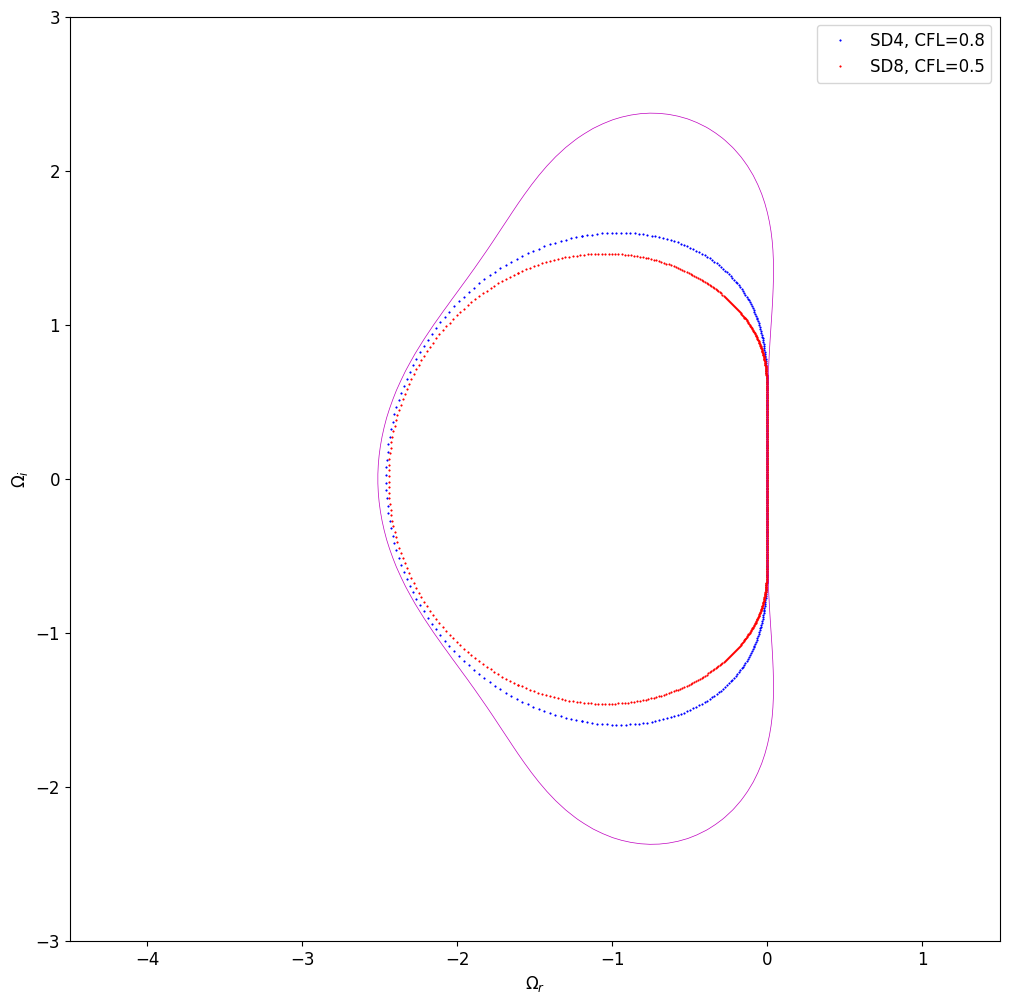

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))

ax.set_xlabel(r"$\Omega_r$")
ax.set_ylabel(r"$\Omega_i$")

plot_eigen(ax,p=3,color="b",cfl=0.8,markersize=2,label="SD4, CFL=0.8")
plot_eigen(ax,p=7,color="r",cfl=0.5,markersize=2,label="SD8, CFL=0.5")

ax.set_xlim([-4.5,1.5])
ax.set_ylim([-3,3])

plot_stab(ax,p=2,color="m")

ax.legend()
fig.savefig("sd_stability.pdf")